In [ ]:
import pandas as pd

# Load datasets
events = pd.read_csv("floodevents_indofloods.csv")
rain = pd.read_csv("precipitation_variables_indofloods.csv")
metadata = pd.read_csv("metadata_indofloods.csv")
catchment = pd.read_csv("catchment_characteristics_indofloods.csv")

# Merge events + precipitation (1:1 on EventID)
df = events.merge(rain, on="EventID")

In [ ]:
df.head()

,EventID,Start Date,End Date,Peak Flood Level (m),Peak FL Date,Num Peak FL,Peak Discharge Q (cumec),Peak Discharge Date,Flood Volume (cumec),Event Duration (days),...,T1d,T2d,T3d,T4d,T5d,T6d,T7d,T8d,T9d,T10d
0,INDOFLOODS-gauge-1010-1,2010-07-21,2010-07-21,47.95,2010-07-21,1,NaN,NaN,NaN,1,...,32.833274,65.228899,99.413481,124.272676,133.344557,138.143367,140.458797,155.228323,177.372062,203.686949
1,INDOFLOODS-gauge-1010-2,2016-07-23,2016-07-23,48.05,2016-07-23,1,NaN,NaN,NaN,1,...,27.011286,60.147585,86.528438,111.753411,136.083522,158.516418,197.476361,216.301547,243.307830,247.079665
2,INDOFLOODS-gauge-1010-3,2016-07-26,2016-07-26,48.00,2016-07-26,1,NaN,NaN,NaN,1,...,50.413312,82.466743,124.859376,151.870662,185.006961,211.387814,236.612787,260.942897,283.375793,322.335737
3,INDOFLOODS-gauge-1010-4,2017-08-11,2017-08-13,48.95,2017-08-12,1,NaN,NaN,NaN,3,...,46.282306,86.765681,104.849158,115.481116,125.934658,130.959363,134.251184,148.829043,167.936433,182.415493
4,INDOFLOODS-gauge-1012-1,2010-07-21,2010-07-21,48.10,2010-07-21,1,NaN,NaN,NaN,1,...,86.018135,137.676182,176.841432,203.447235,215.046211,225.184558,239.477965,284.881663,411.163733,522.828973


In [ ]:
df.to_csv("Events_ID.csv", index=False)

In [ ]:
import pandas as pd

events = pd.read_csv("floodevents_indofloods.csv")
rain = pd.read_csv("precipitation_variables_indofloods.csv")
metadata = pd.read_csv("metadata_indofloods.csv")
catchment = pd.read_csv("catchment_characteristics_indofloods.csv")

df = events.merge(rain, on="EventID")

print("After events+rain:", df.shape)

df["EventID"] = df["EventID"].astype(str).str.strip()
df["GaugeID"] = df["EventID"].str.rsplit("-", n=1).str[0]

df = df.merge(metadata, on="GaugeID", how="left")

print("After metadata merge:", df.shape)
print("Missing metadata:", df["Station"].isna().sum())

df = df.merge(catchment, on="GaugeID", how="left")

print("After catchment merge:", df.shape)
print("Missing catchment:", df["Drainage Area"].isna().sum())


After events+rain: (4548, 23)
After metadata merge: (4548, 41)
Missing metadata: 0
After catchment merge: (4548, 148)
Missing catchment: 0


In [ ]:
print(df["Flood Type"].unique())

['Flood' 'Severe Flood']


In [ ]:
print(df.isna().sum().sum())

87585


In [ ]:
important_columns = [
    # Rainfall
    "T1d","T2d","T3d","T4d","T5d","T6d","T7d","T8d","T9d","T10d",

    # Flood info
    "Flood Type",

    # Catchment physical features
    "Drainage Area",
    "Catchment Relief",
    "Drainage Density",
    "Ruggedness Number",

    # Metadata
    "Latitude",
    "Longitude"
]

df = df[important_columns]

In [ ]:
df["Flood Type"] = df["Flood Type"].str.strip()
df["Flood_Label"] = df["Flood Type"].map({
    "Flood": 0,
    "Severe Flood": 1
})

/tmp/ipython-input-1608691592.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Flood Type"] = df["Flood Type"].str.strip()
/tmp/ipython-input-1608691592.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Flood_Label"] = df["Flood Type"].map({


In [ ]:
print(df.isna().sum())

T1d                  0
T2d                  0
T3d                  0
T4d                  0
T5d                  0
T6d                  0
T7d                  0
T8d                  0
T9d                  0
T10d                 0
Flood Type           0
Drainage Area        0
Catchment Relief     0
Drainage Density     0
Ruggedness Number    0
Latitude             0
Longitude            0
Flood_Label          0
dtype: int64


In [ ]:
print(df.shape)
print(df["Flood_Label"].value_counts())

(4548, 18)
Flood_Label
0    2919
1    1629
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier

X = df.drop(["Flood Type", "Flood_Label"], axis=1)
y = df["Flood_Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[504  78]
 [158 170]]
              precision    recall  f1-score   support

           0       0.76      0.87      0.81       582
           1       0.69      0.52      0.59       328

    accuracy                           0.74       910
   macro avg       0.72      0.69      0.70       910
weighted avg       0.73      0.74      0.73       910



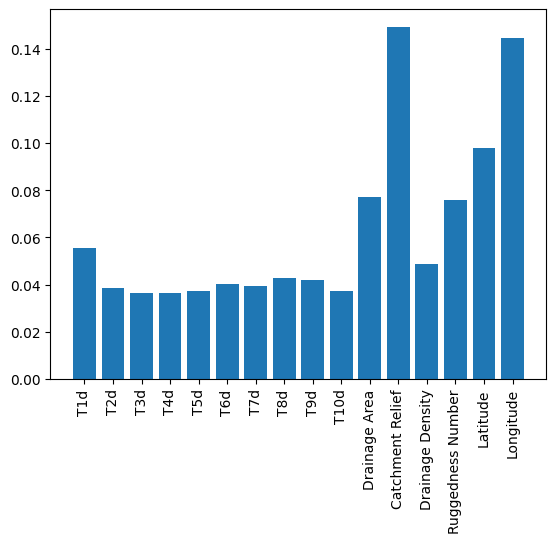

In [ ]:
import matplotlib.pyplot as plt

plt.bar(X.columns, model.feature_importances_)
plt.xticks(rotation=90)
plt.show()

Confusion Matrix:
[[381 201]
 [ 89 239]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.65      0.72       582
           1       0.54      0.73      0.62       328

    accuracy                           0.68       910
   macro avg       0.68      0.69      0.67       910
weighted avg       0.71      0.68      0.69       910



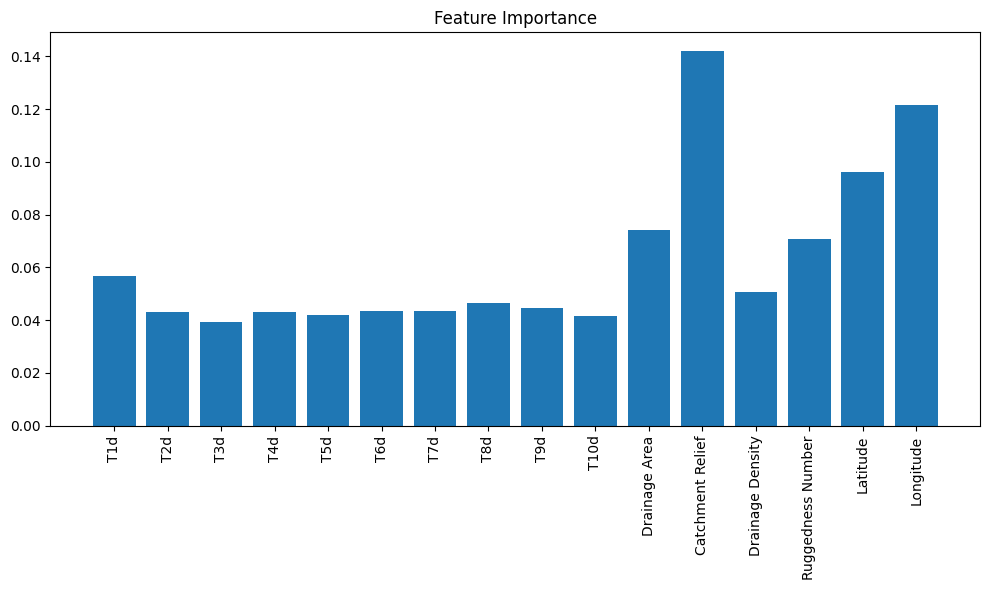

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier

# ---------------------------
# Prepare Data
# ---------------------------

X = df.drop(["Flood Type", "Flood_Label"], axis=1)
y = df["Flood_Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------------------------
# Handle Class Imbalance
# ---------------------------

scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

# ---------------------------
# Improved Model
# ---------------------------

model = XGBClassifier(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)

model.fit(X_train, y_train)

# ---------------------------
# Threshold Adjustment
# ---------------------------

y_prob = model.predict_proba(X_test)[:, 1]

# Lower threshold to increase severe recall
threshold = 0.40
y_pred = (y_prob > threshold).astype(int)

# ---------------------------
# Evaluation
# ---------------------------

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ---------------------------
# Feature Importance Plot
# ---------------------------

plt.figure(figsize=(10,6))
plt.bar(X.columns, model.feature_importances_)
plt.xticks(rotation=90)
plt.title("Feature Importance")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.6813186813186813


In [ ]:
# ---------------------------
# Preview Dataset
# ---------------------------

print("Shape of dataset:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nFirst 5 rows:")
print(df.head())

print("\nClass distribution:")
print(df["Flood_Label"].value_counts())

# ---------------------------
# Save to CSV
# ---------------------------

output_filename = "final_merged_flood_severity_dataset.csv"

df.to_csv(output_filename, index=False)

print(f"\nDataset successfully saved as '{output_filename}'")

Shape of dataset: (4548, 18)

Columns:
Index(['T1d', 'T2d', 'T3d', 'T4d', 'T5d', 'T6d', 'T7d', 'T8d', 'T9d', 'T10d',
       'Flood Type', 'Drainage Area', 'Catchment Relief', 'Drainage Density',
       'Ruggedness Number', 'Latitude', 'Longitude', 'Flood_Label'],
      dtype='object')

First 5 rows:
         T1d         T2d         T3d         T4d         T5d         T6d  \
0  32.833274   65.228899   99.413481  124.272676  133.344557  138.143367   
1  27.011286   60.147585   86.528438  111.753411  136.083522  158.516418   
2  50.413312   82.466743  124.859376  151.870662  185.006961  211.387814   
3  46.282306   86.765681  104.849158  115.481116  125.934658  130.959363   
4  86.018135  137.676182  176.841432  203.447235  215.046211  225.184558   

          T7d         T8d         T9d        T10d    Flood Type  \
0  140.458797  155.228323  177.372062  203.686949         Flood   
1  197.476361  216.301547  243.307830  247.079665         Flood   
2  236.612787  260.942897  283.375793  32

Train distribution:
Flood_Label
0    1629
1    1303
Name: count, dtype: int64

Test distribution:
Flood_Label
1    326
0    326
Name: count, dtype: int64

Confusion Matrix:
[[246  80]
 [115 211]]

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.75      0.72       326
           1       0.73      0.65      0.68       326

    accuracy                           0.70       652
   macro avg       0.70      0.70      0.70       652
weighted avg       0.70      0.70      0.70       652


Accuracy: 0.700920245398773


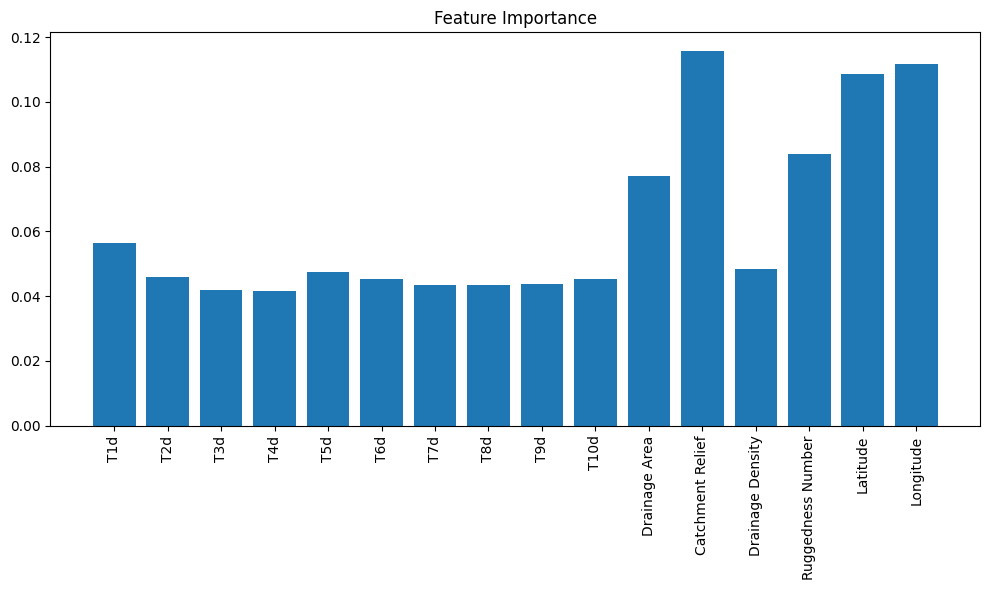

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.utils import shuffle
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from xgboost import XGBClassifier

# ---------------------------------------
# Separate Classes
# ---------------------------------------

df_flood = df[df["Flood_Label"] == 0]
df_severe = df[df["Flood_Label"] == 1]

# Shuffle both classes
df_flood = shuffle(df_flood, random_state=42)
df_severe = shuffle(df_severe, random_state=42)

# ---------------------------------------
# Create Balanced Test Set (326 each)
# ---------------------------------------

test_flood = df_flood.iloc[:326]
test_severe = df_severe.iloc[:326]

df_test = pd.concat([test_flood, test_severe])
df_test = shuffle(df_test, random_state=42)

# ---------------------------------------
# Create Balanced Train Set (1629 each)
# ---------------------------------------

train_flood = df_flood.iloc[326:326+1629]
train_severe = df_severe.iloc[326:326+1629]

df_train = pd.concat([train_flood, train_severe])
df_train = shuffle(df_train, random_state=42)

print("Train distribution:")
print(df_train["Flood_Label"].value_counts())

print("\nTest distribution:")
print(df_test["Flood_Label"].value_counts())

# ---------------------------------------
# Separate Features and Labels
# ---------------------------------------

X_train = df_train.drop(["Flood Type", "Flood_Label"], axis=1)
y_train = df_train["Flood_Label"]

X_test = df_test.drop(["Flood Type", "Flood_Label"], axis=1)
y_test = df_test["Flood_Label"]

# ---------------------------------------
# Train XGBoost (No class weight needed now)
# ---------------------------------------

model = XGBClassifier(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

model.fit(X_train, y_train)

# ---------------------------------------
# Predict
# ---------------------------------------

y_pred = model.predict(X_test)

# ---------------------------------------
# Evaluation
# ---------------------------------------

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:", accuracy)

# ---------------------------------------
# Feature Importance
# ---------------------------------------

plt.figure(figsize=(10,6))
plt.bar(X_train.columns, model.feature_importances_)
plt.xticks(rotation=90)
plt.title("Feature Importance")
plt.tight_layout()
plt.show()

/tmp/ipython-input-2713823996.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Rain_3day"] = df["T3d"]
/tmp/ipython-input-2713823996.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Rain_5day"] = df["T5d"]
/tmp/ipython-input-2713823996.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.h

Dataset shape after feature engineering: (4548, 18)

Train distribution:
Flood_Label
0    2593
1    1303
Name: count, dtype: int64

Test distribution:
Flood_Label
1    326
0    326
Name: count, dtype: int64

Confusion Matrix:
[[299  27]
 [155 171]]

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.92      0.77       326
           1       0.86      0.52      0.65       326

    accuracy                           0.72       652
   macro avg       0.76      0.72      0.71       652
weighted avg       0.76      0.72      0.71       652


Accuracy: 0.7208588957055214


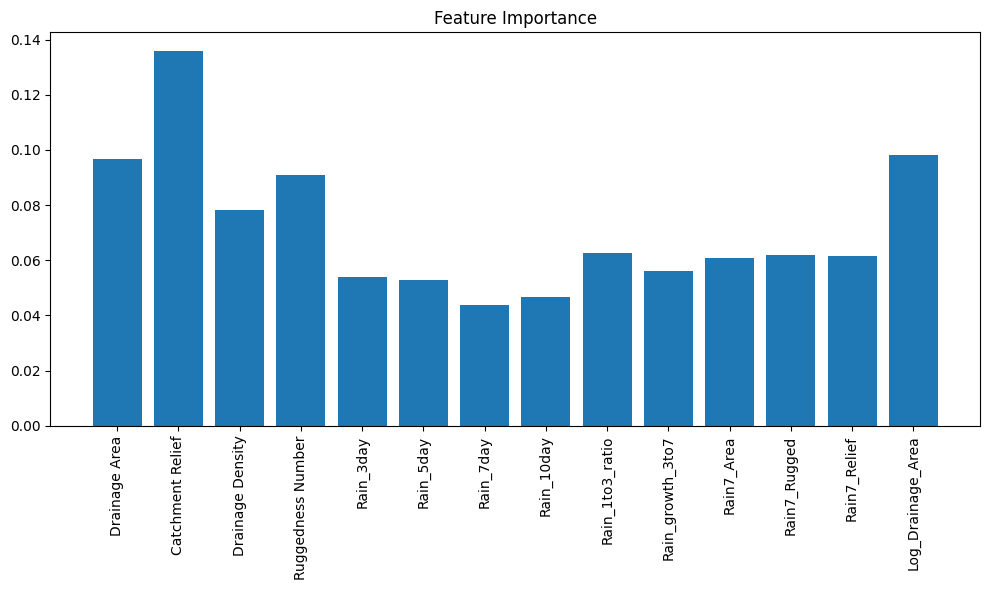

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.utils import shuffle
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from xgboost import XGBClassifier

# ======================================================
# 1️⃣ FEATURE ENGINEERING
# ======================================================

# ----- Rainfall aggregated features -----
df["Rain_3day"] = df["T3d"]
df["Rain_5day"] = df["T5d"]
df["Rain_7day"] = df["T7d"]
df["Rain_10day"] = df["T10d"]

df["Rain_1to3_ratio"] = df["T1d"] / (df["T3d"] + 1e-6)
df["Rain_growth_3to7"] = df["T7d"] - df["T3d"]

# ----- Interaction features -----
df["Rain7_Area"] = df["Rain_7day"] * df["Drainage Area"]
df["Rain7_Rugged"] = df["Rain_7day"] * df["Ruggedness Number"]
df["Rain7_Relief"] = df["Rain_7day"] * df["Catchment Relief"]

df["Log_Drainage_Area"] = np.log1p(df["Drainage Area"])

# ----- Remove raw rainfall columns -----
df = df.drop(
    ["T1d","T2d","T3d","T4d","T5d","T6d","T7d","T8d","T9d","T10d"],
    axis=1
)

print("Dataset shape after feature engineering:", df.shape)

# ======================================================
# 2️⃣ BALANCED TRAIN / TEST SPLIT
# ======================================================

df_flood = df[df["Flood_Label"] == 0]
df_severe = df[df["Flood_Label"] == 1]

df_flood = shuffle(df_flood, random_state=42)
df_severe = shuffle(df_severe, random_state=42)

# ----- Test set (326 each) -----
test_flood = df_flood.iloc[:326]
test_severe = df_severe.iloc[:326]

df_test = pd.concat([test_flood, test_severe])
df_test = shuffle(df_test, random_state=42)

# ----- Train set (remaining data) -----
train_flood = df_flood.iloc[326:]
train_severe = df_severe.iloc[326:]

df_train = pd.concat([train_flood, train_severe])
df_train = shuffle(df_train, random_state=42)

print("\nTrain distribution:")
print(df_train["Flood_Label"].value_counts())

print("\nTest distribution:")
print(df_test["Flood_Label"].value_counts())

# ======================================================
# 3️⃣ SEPARATE FEATURES & LABELS
# ======================================================

X_train = df_train.drop(["Flood Type", "Flood_Label", "Latitude", "Longitude"], axis=1)
y_train = df_train["Flood_Label"]

X_test = df_test.drop(["Flood Type", "Flood_Label", "Latitude", "Longitude"], axis=1)
y_test = df_test["Flood_Label"]

# ======================================================
# 4️⃣ MODEL TRAINING
# ======================================================

model = XGBClassifier(
    n_estimators=500,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

model.fit(X_train, y_train)

# ======================================================
# 5️⃣ PREDICTION
# ======================================================

y_pred = model.predict(X_test)

# ======================================================
# 6️⃣ EVALUATION
# ======================================================

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:", accuracy)

# ======================================================
# 7️⃣ FEATURE IMPORTANCE
# ======================================================

plt.figure(figsize=(10,6))
plt.bar(X_train.columns, model.feature_importances_)
plt.xticks(rotation=90)
plt.title("Feature Importance")
plt.tight_layout()
plt.show()

In [ ]:
!pip install lightgbm

Train distribution:
Flood_Label
0    1303
1    1303
Name: count, dtype: int64

Test distribution:
Flood_Label
1    326
0    326
Name: count, dtype: int64
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1303, number of negative: 1303
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000881 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2819
[LightGBM] [Info] Number of data points in the train set: 2606, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No furthe

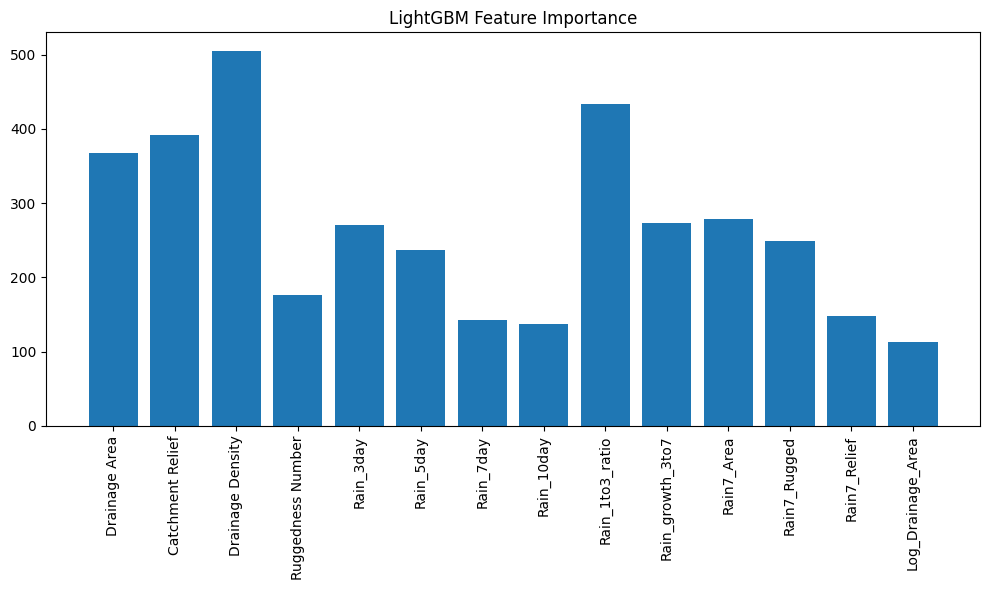

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.utils import shuffle
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from lightgbm import LGBMClassifier

# --------------------------------------------
# Ensure clean copy
# --------------------------------------------
df = df.copy()

# --------------------------------------------
# Balanced Split (326 test each)
# --------------------------------------------

df_flood = df[df["Flood_Label"] == 0]
df_severe = df[df["Flood_Label"] == 1]

df_flood = shuffle(df_flood, random_state=42)
df_severe = shuffle(df_severe, random_state=42)

# Test set
test_flood = df_flood.iloc[:326]
test_severe = df_severe.iloc[:326]

df_test = pd.concat([test_flood, test_severe])
df_test = shuffle(df_test, random_state=42)

# Balanced train set
train_flood = df_flood.iloc[326:326+1303]
train_severe = df_severe.iloc[326:]

df_train = pd.concat([train_flood, train_severe])
df_train = shuffle(df_train, random_state=42)

print("Train distribution:")
print(df_train["Flood_Label"].value_counts())

print("\nTest distribution:")
print(df_test["Flood_Label"].value_counts())

# --------------------------------------------
# Separate features and labels
# --------------------------------------------

X_train = df_train.drop(["Flood Type", "Flood_Label", "Latitude", "Longitude"], axis=1)
y_train = df_train["Flood_Label"]

X_test = df_test.drop(["Flood Type", "Flood_Label", "Latitude", "Longitude"], axis=1)
y_test = df_test["Flood_Label"]

# --------------------------------------------
# LightGBM Model (Shallow Trees)
# --------------------------------------------

model = LGBMClassifier(
    n_estimators=600,
    max_depth=3,              # shallower trees
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

# --------------------------------------------
# Prediction
# --------------------------------------------

y_pred = model.predict(X_test)

# --------------------------------------------
# Evaluation
# --------------------------------------------

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:", accuracy)

# --------------------------------------------
# Feature Importance
# --------------------------------------------

plt.figure(figsize=(10,6))
plt.bar(X_train.columns, model.feature_importances_)
plt.xticks(rotation=90)
plt.title("LightGBM Feature Importance")
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd

from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# -------------------------------------------------
# Prepare Features and Labels
# -------------------------------------------------

X = df.drop(["Flood Type", "Flood_Label", "Latitude", "Longitude"], axis=1)
y = df["Flood_Label"]

# -------------------------------------------------
# Stratified K-Fold Cross Validation
# -------------------------------------------------

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []

# -------------------------------------------------
# LightGBM Model (Shallow Trees)
# -------------------------------------------------

model = LGBMClassifier(
    n_estimators=700,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# -------------------------------------------------
# Cross-Validation Loop
# -------------------------------------------------

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracy_scores.append(accuracy_score(y_test, y_pred))
    precision_scores.append(precision_score(y_test, y_pred))
    recall_scores.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))

    print(f"Fold {fold} accuracy: {accuracy_scores[-1]:.4f}")

# -------------------------------------------------
# Final Results
# -------------------------------------------------

print("\n===== CROSS-VALIDATION RESULTS =====")
print("Mean Accuracy :", np.mean(accuracy_scores))
print("Mean Precision:", np.mean(precision_scores))
print("Mean Recall   :", np.mean(recall_scores))
print("Mean F1-score :", np.mean(f1_scores))


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1303, number of negative: 2335
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001014 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2847
[LightGBM] [Info] Number of data points in the train set: 3638, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.358164 -> initscore=-0.583343
[LightGBM] [Info] Start training from score -0.583343
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive g